---
title: "Insurance Claim Modeling: TabPFN vs. GLM"
description: "Predict insurance pure premiums on zero-inflated claims data; TabPFN on the raw dataframe vs. hand-engineered actuarial GLM, with per-policy uncertainty"
icon: "car-burst"
cookbookTags:
  - regression
  - insurance
authors:
  - name: Philipp Singer
    linkedin: https://www.linkedin.com/in/philippsinger
    twitter: https://twitter.com/ph_singer
---

*Better risk ranking and per-policy uncertainty from the raw dataframe, no feature engineering.*

Insurance claim data is *zero-inflated*: most policies never claim, and the few that do produce
heavily right-skewed amounts. Pricing it well is the core actuarial problem, and the classic recipe
is a **two-stage generalized linear model (GLM)**: a frequency model (how often do claims happen?)
times a severity model (how large are they?). Making a GLM work takes real feature engineering, 
binning, one-hot encoding, log-scaling, and choosing link functions and a Tweedie power by hand.

[TabPFN](https://github.com/PriorLabs/TabPFN) is a tabular foundation model that learns in a single
forward pass with **no per-dataset training and no preprocessing**, you hand it the raw dataframe
(mixed numeric and string columns, missing values and all). This notebook puts TabPFN head-to-head
with matching scikit-learn GLM baselines on the standard French Motor Third-Party Liability
(freMTPL2) dataset.

**Bottom line up front:**

- **Better risk ranking, zero feature engineering.** Straight from the 9-column raw dataframe, TabPFN
  reaches an exposure-weighted **Gini of ~0.32 vs ~0.31** for the best hand-built GLM, better
  separation of safe from risky policies, which is what drives pricing.
- **Per-policy uncertainty for free.** TabPFN returns a full predictive distribution per policy, so
  you can read the expected claim *and* the tail ("how bad could this one get?"), the GLM gives you
  only a fitted mean.
- **Calibration on par, with one optional line.** With a single portfolio-level rescale — the same balancing a log-link GLM does implicitly —
  TabPFN matches the GLM on calibration while leaving the ranking untouched.

We score with the metrics actuaries actually use: the **exposure-weighted Gini** (ranking / lift) and
**Tweedie deviance / D²** (calibration).

> **Requirements.** A CUDA GPU (H100-class recommended for the full dataset). The first TabPFN call
> downloads the model weights. Baselines, dataset explanation and metrics follow scikit-learn's
> [Tweedie regression on insurance claims](https://scikit-learn.org/stable/auto_examples/linear_model/plot_tweedie_regression_insurance_claims.html) example which motivated this tutorial.


In [ ]:
#!pip install tabpfn_client matplotlib scikit-learn

In [27]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer, OneHotEncoder, StandardScaler, FunctionTransformer,
)
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.metrics import mean_tweedie_deviance, d2_tweedie_score, auc


# Benign numeric overflow in TabPFN's inverse target transform (expm1 on the far
# tail of the output distribution's support); results are unaffected.
warnings.filterwarnings("ignore", message="overflow encountered in exp")

RANDOM_STATE = 0
N_ESTIMATORS = 8
FEATURES = ["VehAge", "DrivAge", "VehBrand", "VehPower", "VehGas",
            "Region", "Area", "BonusMalus", "Density"]

In this notebook, we use the TabPFN CLient accessing the API; no hardware required when running the model.

In [29]:
from tabpfn_client import TabPFNClassifier, TabPFNRegressor, get_access_token
token = get_access_token()

# uncomment for local version
# from tabpfn import TabPFNClassifier, TabPFNRegressor

## The data

Each row is an insurance **policy** — a contract between the insurer and a policyholder — described
by driver age, vehicle age, vehicle power, region, and so on. A **claim** is a request for
compensation; the **claim amount** is what the insurer pays out. **Exposure** is how long the policy
was actually observed, measured in years: a policy on the books for the full period has
`Exposure = 1.0`, one observed for six months has `Exposure ≈ 0.5`. It matters because a policy
watched for two months has had far less opportunity to claim than one watched all year, so every
rate below is expressed *per unit of exposure*.

Our target is the **pure premium**: the expected claim cost per unit of exposure, i.e., the
break-even price of the risk. There are two classic ways to model it:

- **Single-stage:** model the total claim cost per unit exposure directly.
- **Two-stage:** model the claim *frequency* (claims per year) and the *severity* (average amount per
  claim) separately, then multiply.

The column `reMTPL2freq` holds one row per policy (risk features, claim count `ClaimNb`, and `Exposure`), `freMTPL2sev` holds the individual claim amounts. We aggregate claim amounts per policy and join;
policies with no claim get `ClaimAmount = 0`. We apply the same light cleaning as the scikit-learn
example (cap extreme values, make `ClaimNb` consistent with `ClaimAmount`) and derive the targets
`Frequency = ClaimNb / Exposure`, `AvgClaimAmount = ClaimAmount / ClaimNb`, and
`PurePremium = ClaimAmount / Exposure`.

Note the feature columns: `VehBrand`, `VehGas`, `Region`, `Area` are **strings**, the rest are
numeric on very different scales. A GLM cannot consume this directly; TabPFN can.


In [30]:
freq = fetch_openml(data_id=41214, as_frame=True).frame   # policies: features + ClaimNb + Exposure
sev = fetch_openml(data_id=41215, as_frame=True).frame     # individual claim amounts

df = freq.copy()
df["ClaimAmount"] = df["IDpol"].map(sev.groupby("IDpol")["ClaimAmount"].sum()).fillna(0.0)

# Standard cleaning.
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=200_000)
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] >= 1), "ClaimNb"] = 0

# Insurance companies are interested in modeling the Pure Premium, that is
# the expected total claim amount per unit of exposure for each policyholder
# in their portfolio:
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]

# This can be indirectly approximated by a 2-step modeling: the product of the
# Frequency times the average claim amount per claim:
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

zero = (df["ClaimAmount"] == 0).mean()
print(f"{len(df):,} policies | {100 * zero:.1f}% have ZERO claim amount | "
      f"{(df.ClaimAmount > 0).sum():,} claims")
df[FEATURES + ["Exposure", "ClaimNb", "ClaimAmount", "PurePremium", "Frequency", "AvgClaimAmount"]].sort_values("ClaimAmount", ascending=False).head()

678,013 policies | 96.3% have ZERO claim amount | 24,944 claims


,VehAge,DrivAge,VehBrand,VehPower,VehGas,Region,Area,BonusMalus,Density,Exposure,ClaimNb,ClaimAmount,PurePremium,Frequency,AvgClaimAmount
147894,1,21,B3,7,'Diesel',R53,C,90,108,0.85,1,200000.0,2.352941e+05,1.176471,200000.0
396360,18,78,B10,7,'Regular',R93,E,50,4762,0.58,1,200000.0,3.448276e+05,1.724138,200000.0
231941,13,21,B1,4,'Diesel',R24,A,140,37,0.16,2,200000.0,1.250000e+06,12.500000,100000.0
270621,14,18,B2,4,'Regular',R82,D,100,863,0.32,1,200000.0,6.250000e+05,3.125000,200000.0
609318,2,33,B12,10,'Regular',R94,D,80,645,0.53,2,200000.0,3.773585e+05,3.773585,100000.0


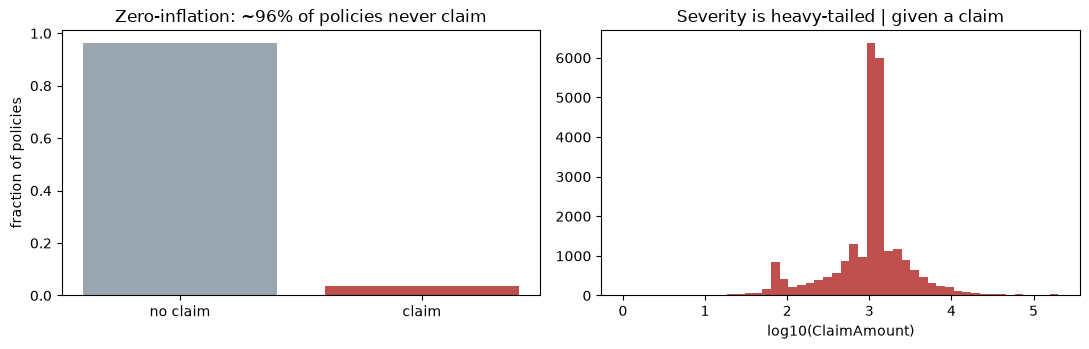

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["no claim", "claim"],
          [(df.ClaimAmount == 0).mean(), (df.ClaimAmount > 0).mean()],
          color=["#9aa7b0", "#c0504d"])
ax[0].set_ylabel("fraction of policies")
ax[0].set_title("Zero-inflation: ~96% of policies never claim")

pos = df.loc[df.ClaimAmount > 0, "ClaimAmount"]
ax[1].hist(np.log10(pos), bins=50, color="#c0504d")
ax[1].set_xlabel("log10(ClaimAmount)")
ax[1].set_title("Severity is heavy-tailed | given a claim")
plt.tight_layout()
plt.show()

We hold out 25% of policies for testing with a **random** split. A production pricing model would
usually be validated *out of time* (train on older policy years, test on newer) to catch drift, but
freMTPL2 ships without a usable time index, so we follow the scikit-learn example and split at
random; a simplification worth remembering for similar use cases.


In [32]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=RANDOM_STATE)
pp_true = df_test["PurePremium"].to_numpy()
weight = df_test["Exposure"].to_numpy()          # exposure-weighting for the metrics
print(f"train {len(df_train):,} | test {len(df_test):,}")

train 508,509 | test 169,504


## Metrics

Two questions matter for a pricing model, and they need different metrics.

**Ranking / lift — does the model sort safe from risky policies?** This is what segmentation and
pricing rely on, and our headline metric. We use the **exposure-weighted Gini**. Sort policies from
safest to riskiest by predicted premium, then trace the cumulative share of *actual* claim cost
against the cumulative share of exposure — the Lorenz curve $L(u)$. The Gini is (twice) the area
between that curve and the diagonal:

$$\mathrm{Gini} = 1 - 2\int_0^1 L(u)\,du$$

Higher is better; a model with no information scores 0. In code it is `1 - 2 * auc(cum_exposure,
cum_claims)`.

**Calibration — is the predicted premium level right?** We use the **Tweedie deviance** (lower is
better) and its normalized cousin **D²** (higher is better, an R²-style score), the standard loss for
zero-inflated, right-skewed cost targets. This is exactly the GLM's own training objective.

We deliberately skip MAE (degenerate on a 96%-zero target — it rewards predicting near-zero for
everyone) and RMSE (dominated by a handful of catastrophic claims).


In [33]:
def gini_exposure(y_true, y_pred, exposure):
    order = np.argsort(y_pred)                     # ascending: safest -> riskiest
    exp = np.asarray(exposure)[order]
    claim = np.asarray(y_true)[order] * exp
    cum_claim = np.cumsum(claim) / claim.sum()
    cum_exp = np.cumsum(exp) / exp.sum()
    return 1 - 2 * auc(cum_exp, cum_claim)

def scores(pred):
    pred = np.clip(pred, 1e-6, None)               # Tweedie deviance needs strictly positive
    return {
        "Gini (exposure)  up": gini_exposure(pp_true, pred, weight),
        "D2 (Tweedie 1.9)  up": d2_tweedie_score(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.9  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.5  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.5),
    }

## GLM baselines

A GLM (generalized linear model) is a linear model with a link function — here a log link, so
predictions stay positive. Being linear, every feature has to be hand-engineered into a numeric
design matrix: bin the skewed numerics, one-hot the categoricals, log-and-scale the heavy-tailed one.
On that shared design matrix we fit the two classic recipes for the pure premium — a **single-stage**
direct Tweedie model, then the **two-stage** frequency × severity product.

The hyperparameters (Tweedie power, regularization strengths) are taken straight from the
scikit-learn tutorial and left untuned; in practice you would grid-search them. That cuts both ways
in this comparison — TabPFN is also run untuned, on its defaults.


### Single-stage GLM: direct Tweedie on pure premium

The simplest recipe: one `TweedieRegressor` fit straight on `PurePremium`, weighted by `Exposure`. No
occurrence/severity split — a single model for the whole target. We set `power=1.9` following the
scikit-learn tutorial.


In [8]:
def make_glm_preprocessor():
    # A fresh ColumnTransformer per model (so fitting one does not overwrite another).
    log_scale = make_pipeline(FunctionTransformer(np.log, validate=False), StandardScaler())
    return ColumnTransformer([
        ("binned", KBinsDiscretizer(n_bins=10, random_state=RANDOM_STATE), ["VehAge", "DrivAge"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore"),
         ["VehBrand", "VehPower", "VehGas", "Region", "Area"]),
        ("passthrough", "passthrough", ["BonusMalus"]),
        ("log_scaled", log_scale, ["Density"]),
    ], remainder="drop")

Xtr = df_train[FEATURES]
n_design = make_glm_preprocessor().fit_transform(Xtr).shape[1]
print(f"GLM design matrix: {n_design} engineered columns from {len(FEATURES)} raw features")

# Single-stage: a direct Tweedie model on the pure premium, weighted by exposure.
glm_tweedie = Pipeline([("prep", make_glm_preprocessor()),
                        ("reg", TweedieRegressor(power=1.9, alpha=0.1, max_iter=1000))])
glm_tweedie.fit(Xtr, df_train["PurePremium"], reg__sample_weight=df_train["Exposure"])
pp_glm_tweedie = glm_tweedie.predict(df_test[FEATURES])
scores(pp_glm_tweedie)

GLM design matrix: 75 engineered columns from 9 raw features


{'Gini (exposure)  up': 0.28834550102009937,
 'D2 (Tweedie 1.9)  up': 0.013735296391564011,
 'Tweedie dev 1.9  down': 33.878261888130645,
 'Tweedie dev 1.5  down': 76.40873870601743}

### Two-stage GLM: frequency × severity

The classic actuarial product: a **Poisson** frequency model (how often claims happen, weighted by
exposure) times a **Gamma** severity model (average amount per claim, fit on claim rows only and
weighted by claim count). Their product is the expected cost per unit exposure. Again, we follow the
scikit-learn tutorial and set the hyperparameters accordingly.


In [9]:
# Stage 1 - frequency: Poisson, weighted by exposure.
glm_freq = Pipeline([("prep", make_glm_preprocessor()),
                     ("reg", PoissonRegressor(alpha=1e-4, max_iter=500))])
glm_freq.fit(Xtr, df_train["Frequency"], reg__sample_weight=df_train["Exposure"])

# Stage 2 - severity: Gamma on claim rows only, weighted by claim count.
claim = df_train["ClaimAmount"] > 0
glm_sev = Pipeline([("prep", make_glm_preprocessor()),
                    ("reg", GammaRegressor(alpha=10.0, max_iter=500))])
glm_sev.fit(Xtr[claim.values], df_train.loc[claim, "AvgClaimAmount"],
            reg__sample_weight=df_train.loc[claim, "ClaimNb"])

pp_glm_product = glm_freq.predict(df_test[FEATURES]) * glm_sev.predict(df_test[FEATURES])
scores(pp_glm_product)

{'Gini (exposure)  up': 0.30667623396467025,
 'D2 (Tweedie 1.9)  up': 0.014606241449514612,
 'Tweedie dev 1.9  down': 33.84834486417605,
 'Tweedie dev 1.5  down': 76.15988353558402}

## TabPFN

Now the same problem with TabPFN — but we feed the **raw dataframe**: strings, integers and floats
together, no encoding, no scaling, no binning, no per-dataset tuning.

GLMs fold exposure in through `sample_weight` and an offset. TabPFN has neither, so we hand it the
information directly instead:

- **Exposure becomes an ordinary input feature.** TabPFN learns its effect from the data rather than
  you specifying it as an offset. We model the *bounded* `ClaimAmount` rather than the exploding
  per-exposure `PurePremium` (dividing a claim by a tiny exposure blows up the tail).
- **The pure premium is read off with a counterfactual query.** We predict every test policy at a
  full year of exposure (`Exposure = 1.0`), so the output is already the expected cost per unit of
  exposure, no division needed.


### Single-stage TabPFN: regress the claim amount directly

Start with the simplest thing that could work: hand a single `TabPFNRegressor` the raw, 96%-zero
`ClaimAmount` and query at full exposure. One `.fit()`, one `.predict()`, default settings — nothing
else. `.predict()` returns the mean of TabPFN's predicted distribution, the estimator of expected
cost.


In [10]:
tab_features = FEATURES + ["Exposure"]
X_tr = df_train[tab_features]

# Counterfactual test set: every policy evaluated at a FULL year of exposure.
X_te_unit = df_test[tab_features].copy()
X_te_unit["Exposure"] = 1.0

reg_single = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
reg_single.fit(X_tr, df_train["ClaimAmount"])
pp_single_vanilla = reg_single.predict(X_te_unit)   # plain mean point-estimate
scores(pp_single_vanilla)

00:05 Fitting... Done!
07:10 Predicting... Done!


{'Gini (exposure)  up': 0.30680240684438265,
 'D2 (Tweedie 1.9)  up': -2175.0647170406223,
 'Tweedie dev 1.9  down': 74747.97597409683,
 'Tweedie dev 1.5  down': 692.3590850256587}

The ranking is already competitive, the Gini lands in the same range as the two stage GLM, but the
calibration is off: the Tweedie deviance is enormous and D² is deeply negative. TabPFN's
default target handling is not built for a target that is 96% zeros with a heavy tail on the rest.

The fix is the same one the GLMs bake in through their log link: model the target on a **log scale**.
TabPFN exposes this as a target transform, `1_plus_log` (fit on `log(1 + y)`, invert on output), the
natural choice for monetary amounts. This is the one modeling knob we touch.


In [11]:
reg_single = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_single.fit(X_tr, df_train["ClaimAmount"])
pp_tabpfn_single = reg_single.predict(X_te_unit)    # plain mean point-estimate
scores(pp_tabpfn_single)

00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:05 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


07:06 Predicting... Done!


{'Gini (exposure)  up': 0.3062529264409002,
 'D2 (Tweedie 1.9)  up': -0.1560920028968369,
 'Tweedie dev 1.9  down': 39.71184155492424,
 'Tweedie dev 1.5  down': 98.82921431822498}

Results show that the ranking quality stays intact, while we severely improve the calibration quality.

### Two-stage TabPFN: occurrence × severity

The actuarial decomposition, with no Poisson/Gamma machinery, just two TabPFN models:

- **Stage 1 — occurrence:** a `TabPFNClassifier` for `P(claim > 0)`.
- **Stage 2 — severity:** a `TabPFNRegressor` for `E[ClaimAmount | claim > 0]`, trained on claim rows
  only.

Expected cost is `P(claim) × severity`. Both stages are queried at `Exposure = 1.0`, so the product
is already the pure premium. We use each stage's **mean** here; the next section pulls stage 2's full
predictive distribution for a handful of example policies.


In [12]:
# Stage 1: occurrence  P(claim > 0 | full year)
clf = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf.fit(X_tr, (df_train["ClaimAmount"] > 0).astype(int))
p_claim = clf.predict_proba(X_te_unit)[:, list(clf.classes_).index(1)]

00:06 Fitting... Done!
07:18 Predicting... Done!


In [17]:
# Stage 2: severity  E[ClaimAmount | claim > 0], trained on claim rows only.
pos = (df_train["ClaimAmount"] > 0).values
reg_sev = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_sev.fit(X_tr[pos], df_train.loc[pos, "ClaimAmount"])
sev_mean = reg_sev.predict(X_te_unit)          # mean severity per policy (point estimate)

pp_tabpfn = p_claim * sev_mean
scores(pp_tabpfn)

00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:05 Fitting... Done!
00:18 Predicting... Done!


{'Gini (exposure)  up': 0.32104571636786383,
 'D2 (Tweedie 1.9)  up': -0.02263779649804487,
 'Tweedie dev 1.9  down': 35.127680185355544,
 'Tweedie dev 1.5  down': 82.20730113027466}

We can now see that the two stage TabPFN solution clearly outperforms all other solutions in the important Gini metric.

## Per-policy uncertainty: the whole distribution, not just a number

A GLM's severity model hands you one number per policy — the fitted mean. TabPFN's severity model
returns a **full predictive distribution**: for each policy we can read the expected claim *and* any
quantile of how large it might be. In insurance that tail is not a nice-to-have — the 90th- or
99th-percentile claim is what drives risk loading, capital and reinsurance.

We only need this for a few illustrative policies, so we ask stage 2 for the full output
(`output_type="full"`) on a small subset. (The hosted client caps full regression output at a few
hundred rows per call — plenty here, since we just want a spread of examples across the risk range.)


In [25]:
# Pick a spread of example policies across the predicted-severity range, then request the
# FULL predictive distribution for just those (the client caps full output at a few hundred rows).
order = np.argsort(sev_mean)
sel = order[np.linspace(0, len(order) - 1, 80).astype(int)]

dist = reg_sev.predict(X_te_unit.iloc[sel], output_type="full",
                       quantiles=[0.1, 0.25, 0.5, 0.75, 0.9])
np.asarray(dist["quantiles"]).shape   # (5 quantiles, len(sel) policies)

00:04 Predicting... Done!


(5, 80)

The chart below plots those policies ordered safest → riskiest by predicted severity. The two lines
are the **mean** TabPFN would price on (red, dashed) and the **median** claim (dark); the shaded fan
is the predictive interval — the inner band the 25th–75th percentile, the outer the 10th–90th. The fan
widens toward the risky end: TabPFN is not only predicting a larger claim there, it is telling you the
outcome is *less certain*. That top edge, the plausible worst case, is exactly what a mean-only model
cannot give you.


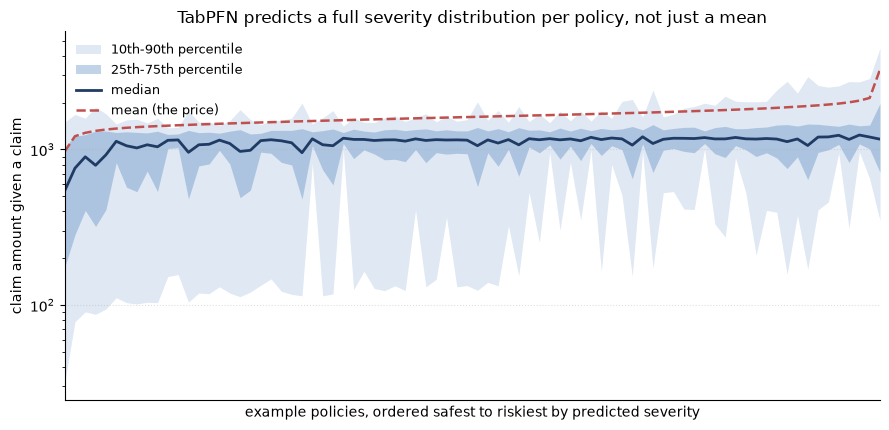

In [26]:
q = np.asarray(dist["quantiles"])            # (5, len(sel)): 0.1, 0.25, 0.5, 0.75, 0.9
p10, p25, median, p75, p90 = q
mean = np.asarray(dist["mean"])
x = np.arange(len(sel))

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.fill_between(x, p10, p90, color="#4f81bd", alpha=0.18, lw=0, label="10th-90th percentile")
ax.fill_between(x, p25, p75, color="#4f81bd", alpha=0.35, lw=0, label="25th-75th percentile")
ax.plot(x, median, color="#1f3b63", lw=2, label="median")
ax.plot(x, mean, color="#c0504d", lw=1.8, ls="--", label="mean (the price)")

ax.set_yscale("log")
ax.margins(x=0)
ax.set_xticks([])
ax.set_xlabel("example policies, ordered safest to riskiest by predicted severity")
ax.set_ylabel("claim amount given a claim")
ax.set_title("TabPFN predicts a full severity distribution per policy, not just a mean")
ax.grid(axis="y", ls=":", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

The same idea as a table: for a few of those policies, the mean claim you would *price* on versus the
90th-percentile claim you would *reserve capital* for. TabPFN gives you both from a single `.predict`;
the GLM's Gamma gives you only the first.


In [20]:
ex = [1, len(sel) // 2, len(sel) - 2]        # positions within the example subset
pd.DataFrame({
    "DrivAge": df_test["DrivAge"].to_numpy()[sel][ex],
    "VehPower": df_test["VehPower"].to_numpy()[sel][ex],
    "mean claim (price)": mean[ex].round(0),
    "P90 claim (tail)": p90[ex].round(0),
}, index=[f"policy {i + 1}" for i in range(len(ex))])

,DrivAge,VehPower,mean claim (price),P90 claim (tail)
policy 1,45,10,1393.0,1488.0
policy 2,25,6,1639.0,1586.0
policy 3,39,6,1897.0,2410.0


## Optional: matching the GLM on calibration

The two-stage TabPFN *ranks* well but **under-prices the portfolio**: summed over the test set it
charges only ~60% of the actual claim cost. A log-link GLM never has this problem, fitting an intercept automatically
balances its predicted total against the observed total on the training data.

We can give TabPFN the same single degree of freedom: one **constant factor** = actual claim cost ÷
predicted cost, estimated on a calibration slice held out of training (never the test set). Because it
is a constant, `c · (p × s)` orders policies exactly like `p × s` — so it fixes the *level* without
moving the *ranking* one bit.

One TabPFN-specific catch: TabPFN predicts by conditioning on its training rows *in-context*, so it
effectively memorizes them — a policy it saw at fit time gets an unrealistically good prediction.
Estimating the factor on such rows would under-correct, so we re-fit both stages on a subset
(`df_fit`) and score the held-out slice (`df_cal`) they never saw.


In [21]:
# Calibration slice held out of TRAIN (never test); models re-fit WITHOUT it so the
# scored rows were not memorized in-context.
df_fit, df_cal = train_test_split(df_train, test_size=0.1, random_state=RANDOM_STATE)
X_fit = df_fit[tab_features]
X_cal_unit = df_cal[tab_features].copy()
X_cal_unit["Exposure"] = 1.0

clf_cal = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf_cal.fit(X_fit, (df_fit["ClaimAmount"] > 0).astype(int))
p_claim_cal = clf_cal.predict_proba(X_cal_unit)[:, list(clf_cal.classes_).index(1)]

pos_fit = (df_fit["ClaimAmount"] > 0).values
reg_cal = TabPFNRegressor(
    n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
    inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)},
)
reg_cal.fit(X_fit[pos_fit], df_fit.loc[pos_fit, "ClaimAmount"])
severity_cal = reg_cal.predict(X_cal_unit)   # mean; plain predict avoids the full-output row cap

# One constant: actual claim cost / predicted cost on the held-out slice (exposure-weighted).
pp_cal = p_claim_cal * severity_cal
c = df_cal["ClaimAmount"].sum() / (pp_cal * df_cal["Exposure"]).sum()

pp_tabpfn_recal = c * pp_tabpfn                    # constant scaling: Gini unchanged

bal_before = (pp_tabpfn * weight).sum() / (pp_true * weight).sum()
bal_after = (pp_tabpfn_recal * weight).sum() / (pp_true * weight).sum()
print(f"rescale factor c = {c:.3f}")
print(f"portfolio balance (predicted / actual): {bal_before:.3f} -> {bal_after:.3f}")
scores(pp_tabpfn_recal)

00:04 Fitting... Done!
04:58 Predicting... Done!
00:06 Fitting... Done!
00:08 Predicting... Done!
rescale factor c = 1.637
portfolio balance (predicted / actual): 0.584 -> 0.956


{'Gini (exposure)  up': 0.32104571636786383,
 'D2 (Tweedie 1.9)  up': 0.00880833559375449,
 'Tweedie dev 1.9  down': 34.04750333782467,
 'Tweedie dev 1.5  down': 77.20614578550321}

## Results

All five models side by side, then two views: the **Lorenz curves** (ranking) and a **decile
calibration chart** (is the premium level right, segment by segment?).


In [22]:
table = pd.DataFrame({
    "GLM Tweedie(1.9)": scores(pp_glm_tweedie),
    "GLM Poisson x Gamma": scores(pp_glm_product),
    "TabPFN single-stage": scores(pp_tabpfn_single),
    "TabPFN two-stage": scores(pp_tabpfn),
    "TabPFN two-stage recal.": scores(pp_tabpfn_recal),
})
table.round(4)

,GLM Tweedie(1.9),GLM Poisson x Gamma,TabPFN single-stage,TabPFN two-stage,TabPFN two-stage recal.
Gini (exposure) up,0.2883,0.3067,0.3063,0.3210,0.3210
D2 (Tweedie 1.9) up,0.0137,0.0146,-0.1561,-0.0226,0.0088
Tweedie dev 1.9 down,33.8783,33.8483,39.7118,35.1277,34.0475
Tweedie dev 1.5 down,76.4087,76.1599,98.8292,82.2073,77.2061


**Lorenz curves.** Policies are sorted safest → riskiest by predicted premium; we plot the cumulative
share of *actual* claim cost against the cumulative share of exposure. A lower, more bowed curve means
better risk separation. Two reference lines frame it: **random** (the diagonal) and the **oracle**
(sorted by realized losses — Gini ~0.98, not 1.0, because claim-bearing policies still occupy a few
percent of the exposure axis). No expected-risk model can reach the oracle: realized claims are mostly
luck, and a model can only rank who is riskier *on average*. The recalibrated two-stage curve overlays
the uncalibrated one exactly — constant rescaling never reorders a single policy.


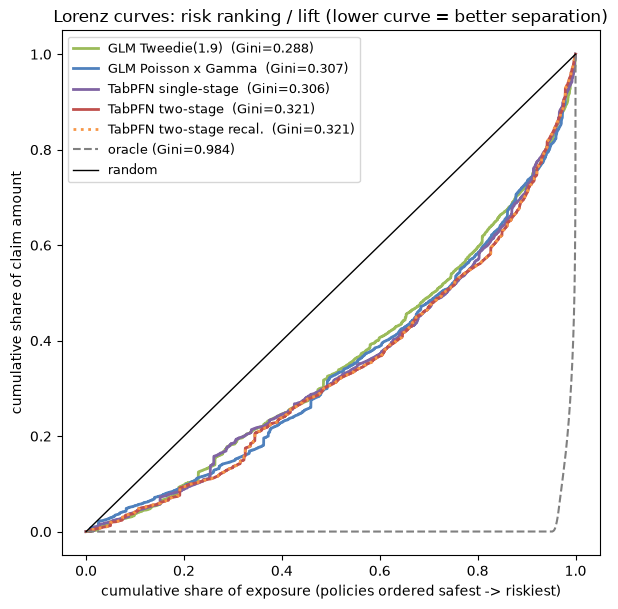

In [23]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
curves = [
    ("GLM Tweedie(1.9)", pp_glm_tweedie, "#9bbb59", "-"),
    ("GLM Poisson x Gamma", pp_glm_product, "#4f81bd", "-"),
    ("TabPFN single-stage", pp_tabpfn_single, "#8064a2", "-"),
    ("TabPFN two-stage", pp_tabpfn, "#c0504d", "-"),
    # Constant rescaling preserves the ordering, so this overlays two-stage exactly.
    ("TabPFN two-stage recal.", pp_tabpfn_recal, "#f79646", ":"),
]
for label, pred, color, ls in curves:
    order = np.argsort(pred)
    exp = weight[order]
    claim = pp_true[order] * exp
    cx = np.insert(np.cumsum(exp) / exp.sum(), 0, 0)
    cy = np.insert(np.cumsum(claim) / claim.sum(), 0, 0)
    ax.plot(cx, cy, color=color, lw=2, ls=ls,
            label=f"{label}  (Gini={gini_exposure(pp_true, pred, weight):.3f})")

order = np.argsort(pp_true)                          # oracle
exp = weight[order]; claim = pp_true[order] * exp
ax.plot(np.insert(np.cumsum(exp) / exp.sum(), 0, 0),
        np.insert(np.cumsum(claim) / claim.sum(), 0, 0),
        "--", color="grey", label=f"oracle (Gini={gini_exposure(pp_true, pp_true, weight):.3f})")
ax.plot([0, 1], [0, 1], color="black", lw=1, label="random")

ax.set_xlabel("cumulative share of exposure (policies ordered safest -> riskiest)")
ax.set_ylabel("cumulative share of claim amount")
ax.set_title("Lorenz curves: risk ranking / lift (lower curve = better separation)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Takeaways

- **Better ranking, zero feature engineering.** From the raw 9-column dataframe — strings and all, one
  `.fit()` / `.predict()` — TabPFN reaches Gini ~0.32 vs ~0.31 for the best GLM. The GLM needed a
  hand-built 75-column design matrix (binning, one-hot, log-scaling) and several modeling choices to
  get there.
- **Uncertainty comes built in.** TabPFN returns a full predictive distribution per policy, so you
  read off the expected claim *and* its tail (the P90 "bad case") directly — exactly what risk loading
  and capital planning need. The GLM gives a mean and stops.
- **Calibration is a one-liner away.** Out of the box TabPFN under-prices the portfolio (it has no
  exposure offset, a genuine convenience the GLMs keep). A single portfolio-level factor — the same
  balancing a log-link GLM performs implicitly — restores the level (balance ~0.6 → ~0.96) and brings
  the Tweedie deviance in line with the GLMs, while provably leaving the ranking untouched.
- **The two-stage split helps TabPFN too.** Occurrence × severity is better calibrated than a single
  regressor on the raw zero-inflated amount — the classic actuarial decomposition still pays off.
- **Match the metric to the question.** Judge *ranking* with the exposure-weighted Gini (the headline
  for pricing) and *calibration* with Tweedie deviance / D² and the decile chart. MAE and RMSE are
  actively misleading on a 96%-zero, heavy-tailed target.
